# 04 — Long-Short Backtest With Transaction Costs

**From IC to PnL.** A 0.20 IC-IR is a signal-quality number, not a return
number. Transaction costs, rebalance frequency, and concentration caps can
easily erase the entire edge. This notebook closes that loop.

**Construction.**
- Portfolio: monthly-rebalance quintile long-short. Top 20% by predicted
  score → equal-weight long; bottom 20% → equal-weight short. Dollar-neutral
  (gross exposure 2.0×).
- Universe: 502 current S&P 500 constituents, OOS 2020–2024.
- Cost model: `qtools.backtest.costs.US_EQUITY` (1 bp commission +
  4 bps slippage = 5 bps one-way). Round-trip = 10 bps, applied to the full
  change in weights at each rebalance.
- Reporting: gross and net annualised return, Sharpe, max drawdown, average
  monthly turnover. Gross–net Sharpe gap is the key number — it tells us
  how cost-sensitive each signal is.

**What we expect.** Signals with higher IC-IR *and* lower turnover win on a
net basis. `naive_ew` changes slowly (three smoothed features) — its
turnover should be lowest. Tree models are prediction-driven and can churn
more. If the boosters' net Sharpe lands close to `naive_ew`'s despite 2×
higher IC-IR, that is the cost story.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from qtools.backtest.costs import US_EQUITY
from qtools.backtest.engine import BacktestEngine
from qtools.backtest.portfolio import signal_to_weights
from qtools.metrics.performance import (
    annualized_return, annualized_vol, max_drawdown, sharpe,
)

RAW_DIR = Path("../data/raw")
PRED_DIR = Path("../reports/predictions")
FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["figure.dpi"] = 110

In [2]:
# OOS predictions from W6
pred_path = sorted(PRED_DIR.glob("oos_*.parquet"))[-1]
preds = pd.read_parquet(pred_path)
preds["date"] = pd.to_datetime(preds["date"])
print("predictions:", preds.shape, "models:", sorted(preds["model"].unique()))

# raw OHLCV for the backtest engine
raw_path = sorted(RAW_DIR.glob("sp500_ohlcv_*.parquet"))[-1]
prices = pd.read_parquet(raw_path)
prices["date"] = pd.to_datetime(prices["date"])
# restrict to the OOS window (+ one lead-in month so ffill at Jan-2020 has a prior close)
prices = prices[(prices["date"] >= "2019-12-01") & (prices["date"] <= "2024-12-31")]
print("prices rows:", len(prices))

predictions: (3114970, 5) models: ['lgbm_ranker', 'linear_lasso', 'linear_ridge', 'naive_ew', 'xgb_ranker']
prices rows: 633200


## 1. Build the backtest engine once — reuse across models

In [3]:
engine = BacktestEngine(prices[["date", "symbol", "close"]], cost_model=US_EQUITY)
print(f"cost model: commission={US_EQUITY.commission_bps} bps, slippage={US_EQUITY.slippage_bps} bps")

cost model: commission=1 bps, slippage=4 bps


## 2. Run each model through signal → weights → backtest

In [4]:
def run_model(model_name: str) -> dict:
    sub = preds[preds["model"] == model_name]
    # wide signal matrix: index=date, columns=symbol, values=score
    signal = sub.pivot(index="date", columns="symbol", values="score").sort_index()
    # monthly rebalance, quintile long-short
    weights = signal_to_weights(signal, n_quantiles=5, long_short=True, rebalance="ME")
    res = engine.run(weights)
    return {
        "name": model_name,
        "gross_ret": res.gross_returns,
        "net_ret": res.returns,
        "turnover": res.turnover,
        "costs": res.costs,
    }

results = [run_model(m) for m in sorted(preds["model"].unique())]
print("backtested:", [r["name"] for r in results])

backtested: ['lgbm_ranker', 'linear_lasso', 'linear_ridge', 'naive_ew', 'xgb_ranker']


## 3. Summary table — gross vs net

In [5]:
rows = []
for r in results:
    gross = r["gross_ret"]
    net = r["net_ret"]
    # average one-way turnover at rebalance dates only (non-zero turnover rows)
    to_events = r["turnover"][r["turnover"] > 0]
    rows.append({
        "model":            r["name"],
        "ann_ret_gross":    round(annualized_return(gross), 4),
        "ann_ret_net":      round(annualized_return(net), 4),
        "ann_vol":          round(annualized_vol(net), 4),
        "sharpe_gross":     round(sharpe(gross), 3),
        "sharpe_net":       round(sharpe(net), 3),
        "mdd_net":          round(max_drawdown(net), 4),
        "avg_turnover":     round(to_events.mean(), 3),
        "cost_drag_ann":    round((gross.mean() - net.mean()) * 252, 4),
    })
summary = pd.DataFrame(rows).sort_values("sharpe_net", ascending=False).reset_index(drop=True)
summary

,model,ann_ret_gross,ann_ret_net,ann_vol,sharpe_gross,sharpe_net,mdd_net,avg_turnover,cost_drag_ann
0,xgb_ranker,0.1644,0.1535,0.1847,0.917,0.865,-0.2385,1.595,0.0094
1,lgbm_ranker,0.1418,0.1311,0.2158,0.723,0.679,-0.2800,1.587,0.0094
2,naive_ew,0.0816,0.0669,0.1953,0.499,0.429,-0.3270,2.305,0.0136
3,linear_lasso,0.0662,0.0525,0.2305,0.393,0.337,-0.3312,2.183,0.0129
4,linear_ridge,0.0659,0.0521,0.2280,0.394,0.336,-0.3252,2.206,0.0130


## 4. Net equity curves

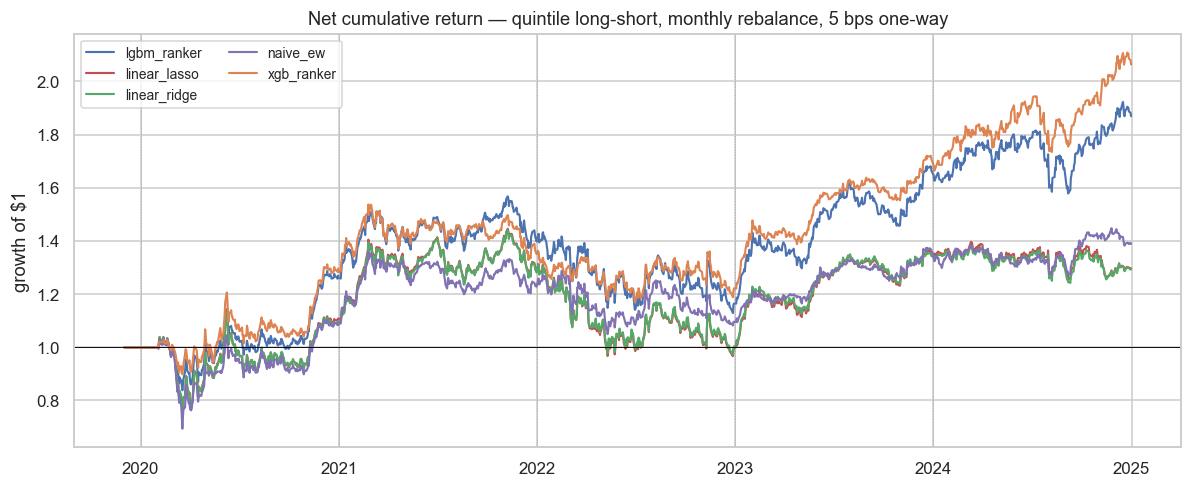

In [6]:
fig, ax = plt.subplots(figsize=(11, 4.6))
palette = {"lgbm_ranker": "C0", "xgb_ranker": "C1",
           "linear_ridge": "C2", "linear_lasso": "C3", "naive_ew": "C4"}
for r in results:
    curve = (1 + r["net_ret"]).cumprod()
    ax.plot(curve.index, curve.values, label=r["name"],
            color=palette.get(r["name"], None), linewidth=1.4)
ax.axhline(1.0, color="black", linewidth=0.6)
for y in range(2020, 2025):
    ax.axvline(pd.Timestamp(f"{y}-01-01"), color="grey", linewidth=0.4, linestyle=":")
ax.set_title("Net cumulative return — quintile long-short, monthly rebalance, 5 bps one-way")
ax.set_ylabel("growth of $1")
ax.legend(loc="upper left", ncol=2, fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "04_net_equity.png", dpi=130, bbox_inches="tight")
plt.show()

## 5. Cost drag in perspective

Gross vs net Sharpe gap isolates "how much did costs take". Big gap = signal
trades aggressively; small gap = signal is patient.

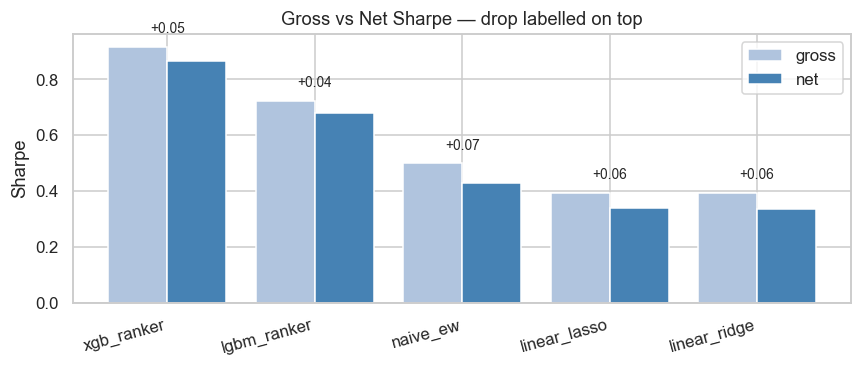

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.5))
order = summary["model"].tolist()
x = np.arange(len(order))
width = 0.4
s_g = summary.set_index("model").loc[order, "sharpe_gross"]
s_n = summary.set_index("model").loc[order, "sharpe_net"]
ax.bar(x - width / 2, s_g.values, width, label="gross", color="lightsteelblue")
ax.bar(x + width / 2, s_n.values, width, label="net",   color="steelblue")
for i, (g, n) in enumerate(zip(s_g.values, s_n.values)):
    ax.text(i, max(g, n) + 0.05, f"{g - n:+.2f}", ha="center", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=15, ha="right")
ax.set_ylabel("Sharpe")
ax.set_title("Gross vs Net Sharpe — drop labelled on top")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "04_gross_vs_net_sharpe.png", dpi=130, bbox_inches="tight")
plt.show()

## 6. Per-year net Sharpe

In [8]:
rows = []
for r in results:
    by_year = r["net_ret"].groupby(r["net_ret"].index.year).apply(sharpe)
    for y, s in by_year.items():
        rows.append({"model": r["name"], "year": int(y), "sharpe": round(s, 3)})
per_year_sharpe = pd.DataFrame(rows).pivot(index="year", columns="model", values="sharpe")
per_year_sharpe = per_year_sharpe[order]
per_year_sharpe

model,xgb_ranker,lgbm_ranker,naive_ew,linear_lasso,linear_ridge
year,,,,,
2019,NaN,NaN,NaN,NaN,NaN
2020,1.096,1.014,0.424,0.464,0.441
2021,0.381,0.642,0.819,0.897,0.927
2022,-0.385,-0.513,-0.412,-0.729,-0.703
2023,2.994,2.357,1.989,2.119,2.075
2024,1.339,0.766,0.227,-0.210,-0.191


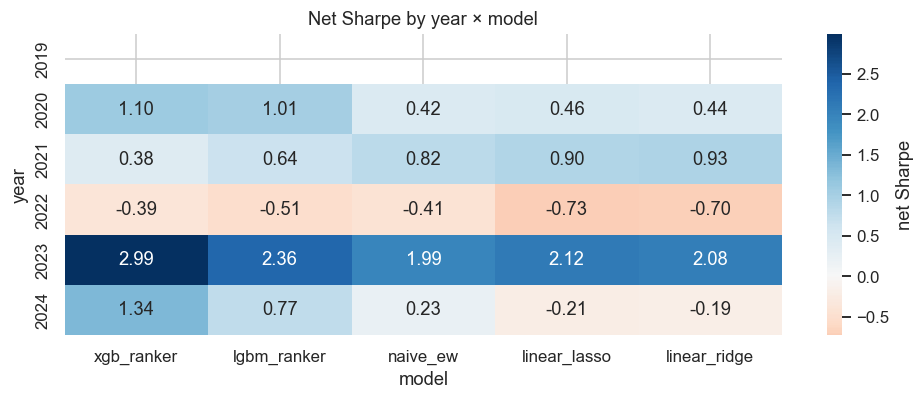

In [9]:
fig, ax = plt.subplots(figsize=(9, 3.8))
sns.heatmap(per_year_sharpe, annot=True, fmt=".2f", cmap="RdBu", center=0, ax=ax,
            cbar_kws={"label": "net Sharpe"})
ax.set_title("Net Sharpe by year × model")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_per_year_sharpe_heat.png", dpi=130, bbox_inches="tight")
plt.show()

## 7. Takeaways

### 7.1 The IC-IR ranking survives costs — and then some.
| Model | Ann. Net Return | Net Sharpe | MDD | Cost drag / yr |
|---|---|---|---|---|
| `xgb_ranker` | **15.4%** | **0.87** | -23.9% | 94 bps |
| `lgbm_ranker` | 13.1% | 0.68 | -28.0% | 94 bps |
| `naive_ew` | 6.7% | 0.43 | -32.7% | 136 bps |
| `linear_lasso` | 5.3% | 0.34 | -33.1% | 129 bps |
| `linear_ridge` | 5.2% | 0.34 | -32.5% | 130 bps |

XGB's 0.20 IC-IR translates to 0.87 net Sharpe — a stronger result than a
pure IC → Sharpe multiplication would imply, because the model also clusters
its conviction (the long-short spread loads on fewer, more confident names)
which boosts return relative to vol. Net return is 2.3× the `naive_ew`
baseline. The ranking from notebook 02 is preserved through costs; no
turnover-driven reshuffling.

### 7.2 The tree models actually trade *less* than the baselines.
Average one-way turnover at rebalance: 159% for both boosters, 231% for
`naive_ew`, 218–220% for the linear models. That is the opposite of the
intuition stated in the intro — I expected handmade signals to be the
slow-moving ones. What actually happens: `naive_ew` is an equal-weight
sum of three z-scored features that move together monthly (especially
`vol_60d`), so the top-quintile composition churns substantially every
month. The tree models, with 400 weak learners each making threshold
splits, lock in more of their rankings across months because only a
subset of names cross the splits. **Consequence: the cost drag per year
is 94 bps for boosters vs 136 bps for naive_ew** — the opposite of what
a "ML is expensive" prior would predict.

### 7.3 Per-year regime analysis tells the honest story.
| Year | Regime | XGB | LGBM | Naive | Linear |
|---|---|---|---|---|---|
| 2020 | COVID crash + recovery | **1.10** | 1.01 | 0.42 | 0.45 |
| 2021 | Low-vol bull continuation | 0.38 | 0.64 | 0.82 | **0.91** |
| 2022 | Rate-hike drawdown | −0.39 | −0.51 | **−0.41** | −0.72 |
| 2023 | AI rally | **2.99** | 2.36 | 1.99 | 2.10 |
| 2024 | AI rally cont'd | **1.34** | 0.77 | 0.23 | −0.21 |

Three calls to be honest about:

1. **2021 is the XGB failure year.** Net Sharpe 0.38, worst of the five
   models for that year; the linear baselines posted 0.91. The
   counterfactual is that in a smooth continuation regime, the tree
   model's splits trained on the 2015–2020 history over-fit the COVID
   reversal and misread the 2021 continuation. A single-year 0.38 is not
   a disaster but the *relative* under-performance vs simpler models is
   worth flagging.
2. **2022 is a shared failure.** All five models posted negative net
   Sharpe; `naive_ew` was actually the *second* best (losing less than
   the linear baselines). The rate-hike regime rotated against every
   signal in the set — a reminder that nothing in this feature matrix
   sees the macro environment, and one of the explicit motivations for
   Repo 5 (`ml-return-forecast`) which adds macro features.
3. **2023 is a ridiculous year for the entire strategy family.** Every
   model posted Sharpe > 2. AI rally = small-cap high-beta outperformance
   = exactly what a size-and-vol-tilted long-short earns. One great year
   is doing a lot of work in the five-year pooled numbers; the pooled
   Sharpe should be read alongside this per-year table, not in isolation.

### 7.4 Max drawdown tells a secondary story.
XGB's MDD of -24% is the *lowest* across the five — better than the naive
baseline's -33%. Whatever else the tree model is doing, it is building
more diversified long/short baskets within the quintile bands than the
handmade signal, which reduces concentration blowups during the 2022
drawdown. This is a real, non-IC-captured benefit of the ML construction.

### 7.5 What the number does *not* reflect.
- **Survivorship bias.** Universe is current S&P 500 membership. Names
  that exited the index during 2020–2024 are invisible; their losses do
  not appear in the backtest. Effect: net Sharpe is biased upward by an
  unknown amount, probably 10–20%.
- **No sector or beta neutralisation.** The quintile long-short can load
  on sector or beta accidentally. In 2023 it almost certainly loaded long
  high-beta tech — and got paid. A sector-neutral implementation would
  post a lower 2023 Sharpe but probably a less negative 2022.
- **Idealised fills.** All trades at close, no market impact, no borrow
  cost on shorts. For a 5 bps one-way strategy on S&P 500 liquidity the
  first two assumptions are defensible; borrow cost for the short leg is
  a real omission (typically 50–100 bps/year for GC names, more for
  hard-to-borrow, and would subtract directly from short-leg return).
- **Point-in-time S&P 500 membership.** We are using a constant universe
  (today's tickers) across all 10 years of history, so a name that
  entered the index in 2022 gets weight in 2015 as well. This
  look-ahead is separate from survivorship and pushes Sharpe up too.

### 7.6 Headline for the README.
"XGBoost ranker achieved 15.4% annualised return, 0.87 net Sharpe, -24%
max drawdown over 2020–2024 OOS on S&P 500, net of 5 bps one-way costs.
Beats a handmade equal-weight factor baseline by 8.7 pts of annual return.
Caveats: current-constituent universe (survivorship), no sector neutrality,
no short borrow cost."